In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit("ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run jupyter lab)")

DATA = data_dir()

# # Solution — Module 4: Classification
#
# **Dataset:** UCI SECOM — McCann, M. & Johnston, A. (2008). *SECOM* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C54305 (CC BY 4.0, https://archive.ics.uci.edu/dataset/179/secom) — `datasets/secom.zip`

In [2]:
import io, zipfile
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
# ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)
plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Leelawadee UI", "Tahoma", "Thonburi"]

with zipfile.ZipFile(DATA / "secom.zip") as z:
    feats = pl.read_csv(io.BytesIO(z.read("secom.data")), separator=" ", has_header=False,
                        new_columns=[f"feature_{i}" for i in range(1, 591)],
                        schema_overrides=[pl.Float64] * 590, null_values="NaN")
    lab = pl.read_csv(io.BytesIO(z.read("secom_labels.data")), separator=" ", quote_char='"',
                      has_header=False, new_columns=["label", "timestamp"])

secom = feats.with_columns(lab["label"].alias("label"))
ts = lab["timestamp"].str.strptime(pl.Datetime, format="%d/%m/%Y %H:%M:%S", strict=False)
secom = secom.with_columns(ts.alias("ts"))

# time-based split — ข้อมูลผลิตมาเป็นลำดับ แบ่งด้วยเวลา ไม่ใช่สุ่ม
n_train = int(len(secom) * 0.8)
train, test = secom.head(n_train), secom.tail(len(secom) - n_train)

# feature = 590 คอลัมน์เซนเซอร์เท่านั้น (label คือคำตอบ, ts ใช้แค่พิสูจน์ลำดับการผลิต)
X_train = train.drop("label", "ts")
X_test = test.drop("label", "ts")

# ## ข้อ A1 — สำรวจข้อมูล: ค่าหายและความไม่สมดุล

In [3]:
n = len(secom)
miss = (secom.drop("label").null_count()
        .transpose(include_header=True, header_name="feature")
        .rename({"column_0": "n_missing"})
        .with_columns(pct_missing=(pl.col("n_missing") / n * 100).round(1))
        .sort("n_missing", descending=True))

total_missing = int(miss["n_missing"].sum())
total_cells = n * 590
print(f"shape = {n} แถว × 590 features + label")
print(f"ค่าหายรวม {total_missing:,} / {total_cells:,} เซลล์ = {total_missing / total_cells * 100:.2f}%")
print(f"feature ที่มีค่าหายอย่างน้อย 1 ค่า: {int((miss['n_missing'] > 0).sum())} / 590")
print("\nTop 5 ที่หายหนักสุด:")
print(miss.head(5))

n_pass = int((secom["label"] == -1).sum())
n_fail = int((secom["label"] == 1).sum())
print(f"\nPASS (-1) = {n_pass}, FAIL (+1) = {n_fail} ({n_fail / n * 100:.1f}%)")

shape = 1567 แถว × 590 features + label
ค่าหายรวม 41,951 / 924,530 เซลล์ = 4.54%
feature ที่มีค่าหายอย่างน้อย 1 ค่า: 538 / 590

Top 5 ที่หายหนักสุด:
shape: (5, 3)
┌─────────────┬───────────┬─────────────┐
│ feature     ┆ n_missing ┆ pct_missing │
│ ---         ┆ ---       ┆ ---         │
│ str         ┆ u32       ┆ f64         │
╞═════════════╪═══════════╪═════════════╡
│ feature_158 ┆ 1429      ┆ 91.2        │
│ feature_159 ┆ 1429      ┆ 91.2        │
│ feature_293 ┆ 1429      ┆ 91.2        │
│ feature_294 ┆ 1429      ┆ 91.2        │
│ feature_86  ┆ 1341      ┆ 85.6        │
└─────────────┴───────────┴─────────────┘

PASS (-1) = 1463, FAIL (+1) = 104 (6.6%)


# **สรุปข้อ A1:** ค่าหาย ~4.54% ของทุกเซลล์ (538/590 feature มีค่าหายบ้าง — หนักสุด ~91% จึงเติม median แล้วเสี่ยงใช้ feature นั้นไม่ได้เลยก็มี) และ fail มีแค่ 6.6% — สองปัญหานี้คือบททดสอบของทุกโมเดลในข้อถัดไป

# ## ข้อ A2 — สี่โมเดลในตารางเดียว

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def make_pipe(model):
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler()),
                     ("model", model)])

n_pos = int((train["label"] == 1).sum())
n_neg = len(train) - n_pos
spw = n_neg / n_pos

models = {
    "Logistic (balanced)": make_pipe(
        LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)),
    "SVM rbf (balanced)": make_pipe(
        CalibratedClassifierCV(SVC(kernel="rbf", class_weight="balanced", random_state=42), ensemble=False)),
    "RandomForest": make_pipe(
        RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                               random_state=42, n_jobs=-1)),
    "XGBoost": make_pipe(
        XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5, scale_pos_weight=spw,
                      random_state=42, eval_metric="logloss")),
}

y01_train = (train["label"] == 1).cast(pl.Int64)   # XGBoost ต้องการ 0/1
y01_test = (test["label"] == 1).cast(pl.Int64)
n_fail_test = int((test["label"] == 1).sum())

rows = []
for name, model in models.items():
    yt = y01_train if name == "XGBoost" else train["label"]
    model.fit(X_train, yt)
    acc_tr = model.score(X_train, yt)
    acc_te = model.score(X_test, y01_test if name == "XGBoost" else test["label"])
    pred = model.predict(X_test)    # fail = ค่า 1 ทั้งสองระบบ label
    lab_true = test["label"].to_numpy()
    flagged = int((pred == 1).sum())
    caught = int(((pred == 1) & (lab_true == 1)).sum())
    fa = int(((pred == 1) & (lab_true == -1)).sum())
    rows.append({"model": name, "acc_train": round(acc_tr, 4), "acc_test": round(acc_te, 4),
                 "ตัดสิน FAIL": flagged, "จับ FAIL ได้": f"{caught}/{n_fail_test}", "false alarm": fa})
    models[name] = model

dummy_acc_test = int((test["label"] == -1).sum()) / len(test)
summary = pl.DataFrame(rows)
print(f"dummy baseline (ตอบ PASS ทุกชิ้น): acc_test = {dummy_acc_test:.4f}")
summary

dummy baseline (ตอบ PASS ทุกชิ้น): acc_test = 0.9459


model,acc_train,acc_test,ตัดสิน FAIL,จับ FAIL ได้,false alarm
str,f64,f64,i64,str,i64
"""Logistic (balanced)""",0.9816,0.9013,20,"""3/17""",17
"""SVM rbf (balanced)""",0.9306,0.9459,0,"""0/17""",0
"""RandomForest""",1.0,0.9459,0,"""0/17""",0
"""XGBoost""",1.0,0.9459,0,"""0/17""",0


# **คำตอบข้อ A2 (ทำไมตาราง accuracy หลอกเรา):** RF กับ XGBoost ได้ acc_test = 0.9459 **เท่ากับ dummy ที่ตอบ PASS ทุกชิ้น** — ทั้งคู่จับ fail ได้ 0 ตัว accuracy สูงเพราะของดีมี 93–95% ไม่ใช่เพราะโมเดลเก่ง ของ fail (17 ชิ้นใน test) คือสิ่งที่ต้องวัด และ accuracy เดียวไม่เห็นมัน — จึงต้องดู confusion matrix / precision-recall (Module 5)

# ## ข้อ A3 — class_weight ทำอะไรกับการจับ fail

In [5]:
plain = make_pipe(LogisticRegression(max_iter=2000, random_state=42))
balanced = make_pipe(LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42))

for name, model in [("plain", plain), ("balanced", balanced)]:
    model.fit(X_train, train["label"])
    acc = model.score(X_test, test["label"])
    pred = model.predict(X_test)
    lab_true = test["label"].to_numpy()
    flagged = int((pred == 1).sum())
    caught = int(((pred == 1) & (lab_true == 1)).sum())
    fa = int(((pred == 1) & (lab_true == -1)).sum())
    print(f"{name:9s} | acc_test = {acc:.4f} | ตัดสิน FAIL {flagged:3d} ชิ้น | "
          f"จับ fail ได้ {caught}/{n_fail_test} | false alarm {fa}")

plain     | acc_test = 0.9299 | ตัดสิน FAIL   9 ชิ้น | จับ fail ได้ 2/17 | false alarm 7
balanced  | acc_test = 0.9013 | ตัดสิน FAIL  20 ชิ้น | จับ fail ได้ 3/17 | false alarm 17


# **คำตอบข้อ A3:** `class_weight="balanced"` ยอมเสีย accuracy (0.9299 → 0.9013) เพื่อจับ fail เพิ่มจาก 2/17 เป็น 3/17 พร้อม false alarm เพิ่มจาก 7 เป็น 17 — มันเท่ากับ "บอกโมเดล" ว่า fail หนึ่งชิ้นสำคัญ ~14 เท่าของ pass ซึ่งคือการตัดสินเชิงต้นทุนที่ฝังอยู่ในโมเดล ไม่ใช่ความแม่นที่เพิ่มขึ้นฟรี ๆ

# ## ข้อ B1 — เลื่อน threshold: จับ fail เพิ่ม แลกกับตัดของดีทิ้ง

In [6]:
proba_fail = balanced.predict_proba(X_test)[:, 1]
lab_true = test["label"].to_numpy()

thr_rows = []
for thr in [0.1, 0.3, 0.5, 0.7]:
    flagged = proba_fail >= thr
    caught = int((flagged & (lab_true == 1)).sum())
    fa = int((flagged & (lab_true == -1)).sum())
    thr_rows.append({"threshold": thr, "ตัดสิน FAIL (ชิ้น)": int(flagged.sum()),
                     "จับ FAIL ได้": f"{caught}/{n_fail_test}",
                     "recall": round(caught / n_fail_test, 2),
                     "false alarm (ตัดของดีทิ้ง)": fa})
pl.DataFrame(thr_rows)

threshold,ตัดสิน FAIL (ชิ้น),จับ FAIL ได้,recall,false alarm (ตัดของดีทิ้ง)
f64,i64,str,f64,i64
0.1,33,"""4/17""",0.24,29
0.3,24,"""3/17""",0.18,21
0.5,20,"""3/17""",0.18,17
0.7,15,"""3/17""",0.18,12


# **สรุปข้อ B1:** threshold ลดจาก 0.7 → 0.1 จับ fail เพิ่ม (2 → 4 จาก 17) แต่ false alarm พุ่งจาก 12 เป็น 29 — สองคอลัมน์ขวาเคลื่อน **ทิศเดียวกัน** ตลอด ไม่มีค่า threshold ที่ชนะทั้งสองฝั่ง การเลือกคือการเลือกต้นทุนที่ยอมจ่าย (เหมือนการตั้ง tolerance limit — กระชับ limit = ตัดของดีทิ้งเพิ่ม แต่ของเสียหลุดน้อยลง)

# ## ข้อ B2 — top-10 feature ที่โมเดลสนใจสุด

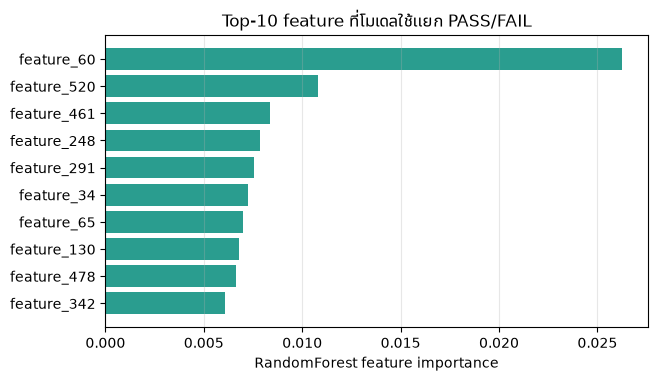

top 10: ['feature_60 (0.0263)', 'feature_520 (0.0108)', 'feature_461 (0.0083)', 'feature_248 (0.0079)', 'feature_291 (0.0075)', 'feature_34 (0.0072)', 'feature_65 (0.0070)', 'feature_130 (0.0068)', 'feature_478 (0.0066)', 'feature_342 (0.0061)']


In [7]:
rf = models["RandomForest"]
imp = rf.named_steps["model"].feature_importances_
top = np.argsort(imp)[::-1][:10]

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh([f"feature_{i + 1}" for i in top][::-1], imp[top][::-1], color="#2a9d8f")
ax.set_xlabel("RandomForest feature importance")
ax.set_title("Top-10 feature ที่โมเดลใช้แยก PASS/FAIL")
ax.grid(alpha=0.3, axis="x")
plt.show()

print("top 10:", [f"feature_{i + 1} ({imp[i]:.4f})" for i in top])

# **คำตอบข้อ B2 (ประโยคเดียว):** สัญญาณของ fail กระจายอยู่หลายเซนเซอร์ร่วมกัน (ตัวนำ ~0.026 จาก 1.0 รวมทั้ง 590) จึงไม่มี probe เดียวที่ชี้ของเสียได้ — แต่ **importance ≠ causation**: อาจเป็นแค่ตัวแทนของดริฟต์เวลา/เงื่อนไขสายผลิต ต้องยืนยันด้วยการทดลองจริงก่อนสรุปสาเหตุ

# ## ข้อ B3 — โจทย์คิด (ตอบใน markdown)

# **คำตอบข้อ B3:**
#
# ถ้าของเสียหลุดแพงกว่า rework **20 เท่า** — ควรกด threshold **ลง** (เช่น 0.3 หรือต่ำกว่า): จากตารางข้อ B1 ที่ t = 0.3 จับ fail ได้ 3/17 พร้อม false alarm 21 ชิ้น ต้นทุน rework 21 ชิ้นคุ้มกันของเสียที่หลุดมากกว่า — ผลข้างเคียงที่ต้องยอมรับคือ operator ต้อง rework/ตรวจซ้ำเยอะขึ้น และถ้าเฟรมของ "ผิดพลาด" กลับไปให้คำนวณต้นทุนรวมต่อชิ้นจะเห็นจุดคุ้มที่แท้จริง
#
# ถ้าสายนี้กลับเป็น "ตัดทิ้งแพงกว่า rework" (ของราคาถูก มาร์จิ้นบาง) — ทิศทางกลับกัน **เพิ่ม threshold** ขึ้น (เช่น 0.7): ยอมให้ของเสียหลุดบ้าง เพราะการกล่าวหาของดีผิด ๆ แพงเกิน — ตรรกะเดียวกับที่ tolerance limit สอบเทียบถูกกระชับหรือคลายตาม "ต้นทุนของความผิดพลาด" ทั้งสองทาง ไม่ใช่ตามความแม่นของเครื่องมืออย่างเดียว